In [1]:
import pandas as pd
import numpy as np
from src import run_experiment, Config
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer, KNNImputer
from matplotlib import pyplot as plt
from collections import Counter


In [2]:
df = pd.read_csv('../data/app_train_nan90.csv')

In [3]:
target = df['TARGET']

In [4]:
Counter(target)

Counter({0: 282685, 1: 24825})

(array([282685.,      0.,      0.,      0.,      0.,      0.,      0.,
             0.,      0.,  24825.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

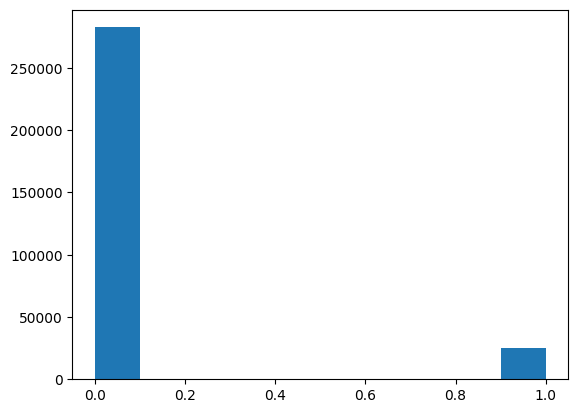

In [5]:
plt.hist(target)

In [6]:
# Солвер 'saga' с penalty='elasticnet' очень долго сходится, поэтому сделаем пока чистую L2-регуляризацию
def log_reg_param_space(trial):
    return {
        "C": trial.suggest_float('C', 1e-3, 1e2, log=True),
        # "l1_ratio": trial.suggest_float('l1_ratio', 0, 1, step=0.1),
        # "penalty": trial.suggest_categorical('penalty', ['elasticnet']),
        # "solver": trial.suggest_categorical('solver', ['saga']),
        "max_iter": trial.suggest_int('max_iter', 100, 1000, step=100)
    }

exp_name_lr = f'90_nan'

# run_experiment(
#     exp_name_lr,
#     LogisticRegression,
#     log_reg_param_space,
#     df,
#     n_trials=1,
#     cv_num=2,
#     save_model=True
# )

In [7]:
from sklearn.tree import DecisionTreeClassifier

def decision_tree_param_space(trial):
    return {
        "criterion": trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"]),
        "max_depth": trial.suggest_int("max_depth", 1, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

exp_name_dt = f'90_nan'

# run_experiment(
#     exp_name_dt,
#     DecisionTreeClassifier,
#     decision_tree_param_space,
#     df,
#     n_trials=1,
#     cv_num=2,
#     save_model=True
# )

In [8]:
from sklearn.ensemble import RandomForestClassifier

def random_forest_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 300),
        "max_depth": trial.suggest_int("max_depth", 1, 13),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False])
    }

exp_name_rf = f'90_nan'

# run_experiment(
#     exp_name_rf,
#     RandomForestClassifier,
#     random_forest_param_space,
#     df,
#     n_trials=1,
#     cv_num=2,
#     save_model=True
# )

In [9]:
from catboost import CatBoostClassifier

def catboost_param_space(trial):
    return {
        "iterations": trial.suggest_int("iterations", 100, 500),
        "depth": trial.suggest_int("depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 0, 1),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        "bootstrap_type": "Bernoulli",
        "verbose": False,
        "random_state": Config.SEED
    }

exp_name_cb = f'90_nan'

# run_experiment(
#     exp_name_cb,
#     CatBoostClassifier,
#     catboost_param_space,
#     df,
#     n_trials=1,
#     cv_num=2,
#     save_model=True
# )

In [10]:
from lightgbm import LGBMClassifier

def lightgbm_param_space(trial):
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 150),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        # "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "objective": "binary",
        "data_sample_strategy": "goss",
        # "early_stopping_round": 50, необходимо передать в fit, а не в конструктор модели
        "metric": "auc",
        "verbose": -1,
        "random_state": Config.SEED
        # можно добавить использование cat_features
    }

# exp_name_lgbm = f'90_nan'

# run_experiment(
#     exp_name_lgbm,
#     LGBMClassifier,
#     lightgbm_param_space,
#     df,
#     n_trials=1,
#     cv_num=5,
#     save_model=False
# )

[I 2026-05-05 01:43:35,158] Using an existing study with name 'XGBClassifier' instead of creating a new one.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   26.4s remaining:   39.6s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   26.5s finished
[I 2026-05-05 01:44:01,833] Trial 11 finished with value: 0.7355655142133264 and parameters: {'learning_rate': 0.2489323150846178, 'max_depth': 5, 'n_estimators': 265, 'subsample': 0.6248126654205947, 'min_child_weight': 6, 'colsample_bytree': 0.777231918720281, 'scale_pos_weight': 1}. Best is trial 8 with value: 0.7545849499348375.
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of   5 | elapsed:   29.8s remaining:   44.7s
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:   31.1s finished
[I 2026-05-05 01:44:33,067] Trial 12 finished with value: 0.7454384855165257 and parameters: {'learn

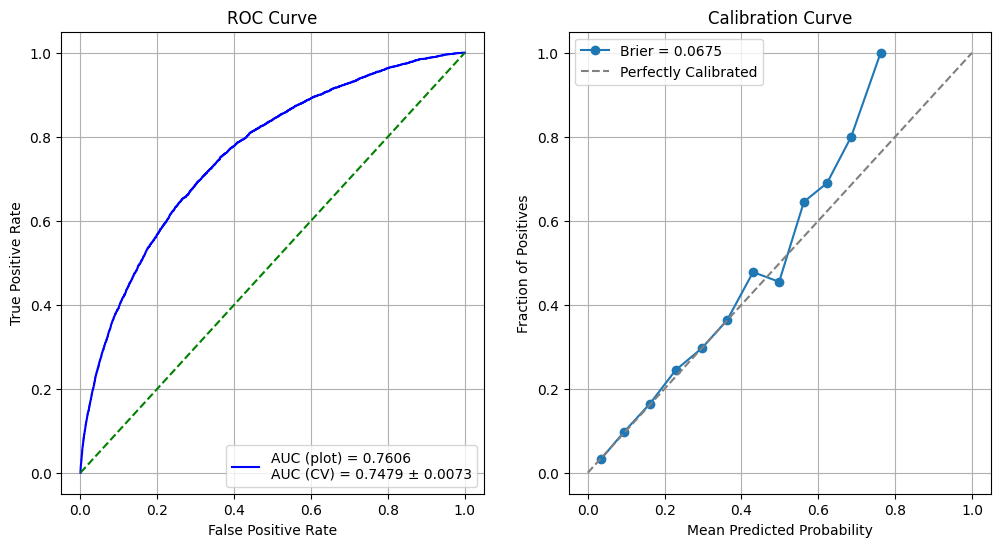

{'auc_mean_cv': '0.7479', 'auc_std_cv': '0.0073', 'brier_score': '0.0675'}

In [ ]:
from xgboost import XGBClassifier

def xgboost_param_space(trial):
    return {
        "verbosity": 0,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 10),
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "scale_pos_weight": trial.suggest_categorical("scale_pos_weight", [1, 11]),
        "objective": "binary:logistic",
        "eval_metric": 'auc',
        "seed": Config.SEED,

        # "gamma"
        # "max_cat_to_onehot"
        # "max_cat_threshold"
        # можно добавить использование cat_features
    }

# mask = target == 0
# sum_pos = np.sum(target, axis=0)
# sum_neg = np.sum(mask)
# print(sum_pos)
# print(sum_neg)
# scale_pos_weight = sum_neg / sum_pos
# print(scale_pos_weight) = 11

exp_name_xgb = f'90_nan'

# CMA-ES с Warm-Starting 
# Meta-Learn TPE — Лучший выбор для TPE

run_experiment(
    exp_name_xgb,
    XGBClassifier,
    xgboost_param_space,
    df,
    n_trials=10,
    cv_num=5,
    save_model=False
)

# Export to the PROD

Из всех моделей осталось выбрать наилучшую по Kaggle-score и дальше через FastAPI & Streamlit UI сделать полноценное приложение.